In [10]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score

In [11]:
df = pd.read_csv("../../data/crime_500k_cleaned.csv")

In [12]:
temporal_features = df[['Hour', 'Day', 'Month', 'Is_Weekend']]

In [13]:
temporal_features.dtypes

Hour          int64
Day           int64
Month         int64
Is_Weekend    int64
dtype: object

In [14]:
scaler = StandardScaler()
X = scaler.fit_transform(temporal_features)

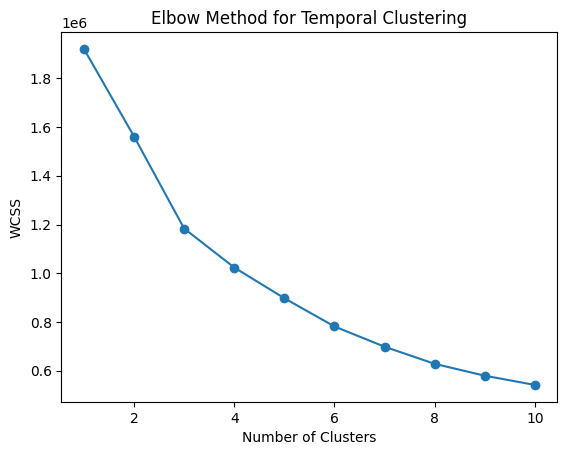

In [15]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker="o")
plt.title("Elbow Method for Temporal Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Temporal_Cluster'] = kmeans.fit_predict(X)

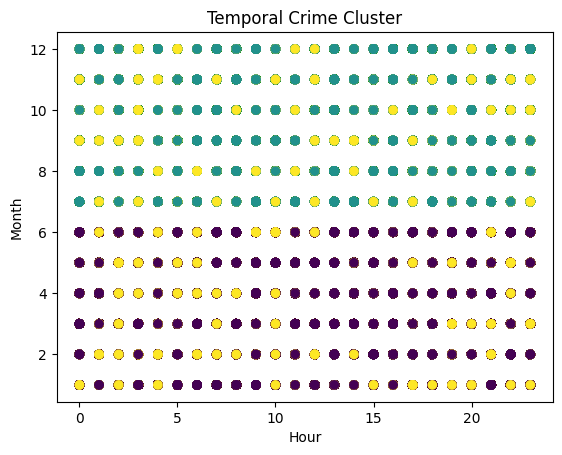

In [17]:
cluster_counts = df["Temporal_Cluster"].value_counts().sort_index()
plt.scatter(df["Hour"], df["Month"], c=df["Temporal_Cluster"])
plt.title("Temporal Crime Cluster")
plt.xlabel("Hour")
plt.ylabel("Month")
plt.show()

In [18]:
# score = silhouette_score(X, df['Temporal_Cluster'])
# print(score)

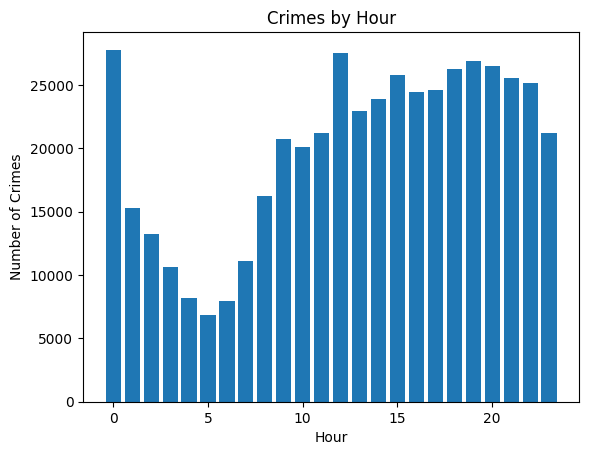

In [19]:
hour = df.groupby('Hour').size()
plt.bar(hour.index, hour.values)
plt.title("Crimes by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Crimes")
plt.show()

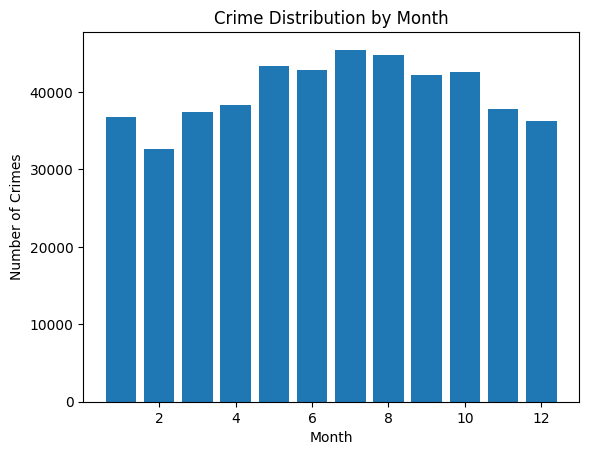

In [20]:
month_counts = df.groupby('Month').size()

plt.bar(month_counts.index, month_counts.values)
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.title("Crime Distribution by Month")
plt.show()

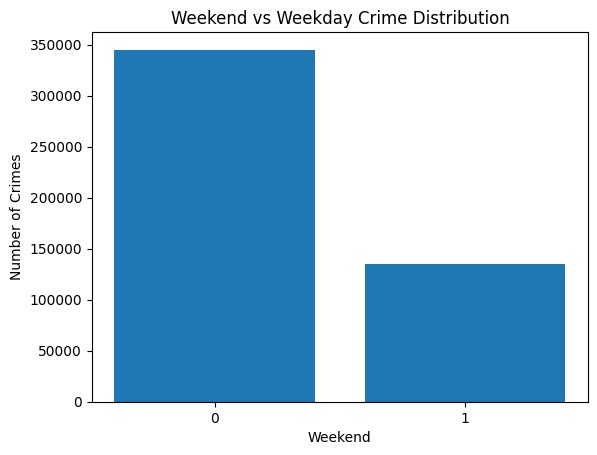

In [21]:
weekend_counts = df.groupby('Is_Weekend').size()

plt.bar(weekend_counts.index.astype(str), weekend_counts.values)
plt.xlabel("Weekend")
plt.ylabel("Number of Crimes")
plt.title("Weekend vs Weekday Crime Distribution")
plt.show()

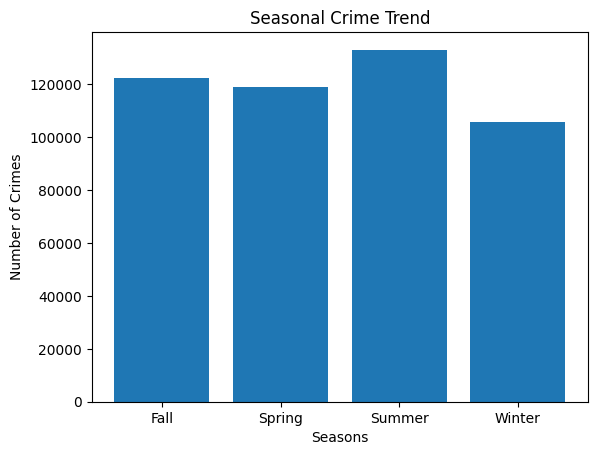

In [23]:
seasons = df.groupby("Season").size()

plt.bar(seasons.index, seasons.values)
plt.title("Seasonal Crime Trend")
plt.xlabel("Seasons")
plt.ylabel("Number of Crimes")
plt.show()